## Load Data

In [14]:
#! pip install mne

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS, FREQ_BANDS

# Define subjects for multi-subject analysis
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

CONDITION  = "BLA"
CHANNELS   = "BLA"   # T7, T8, TP7, TP8
FREQ_BANDS = "beta_gamma"

import warnings
import contextlib
import io

all_epochs = {}
all_data = {}
loaded_subjects = []
failed_subjects = []

for SUBJECT_ID in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(CONDITION, SUBJECT_ID, channels=CHANNELS)

        data = epochs.get_data() * 1e6
        all_epochs[SUBJECT_ID] = epochs
        all_data[SUBJECT_ID] = data
        loaded_subjects.append(SUBJECT_ID)

    except Exception as e:
        failed_subjects.append((SUBJECT_ID, str(e)))

print("Loaded successfully:", loaded_subjects)

if failed_subjects:
    print("\nFailed to load:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")


Loaded successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


## Frequency Domain Analysis - Multiple Subjects

Analyze the power spectral density (PSD) of BLA trials in different frequency bands across multiple subjects to understand oscillatory activity patterns.

Frequency bands:
- Delta: 0.5–4 Hz
- Theta: 4–8 Hz
- Alpha: 8–13 Hz
- Beta: 13–30 Hz
- Gamma: 30–45 Hz

**Subjects to analyze:** 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17 (14 subjects)

In [15]:
# Test the function import
from utils import compute_frequency_power, load_eeg_data
print("Functions imported successfully")

# Define subjects to analyze
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]  # All available BLA subjects
CONDITION = "BLA"
CHANNELS = "BLA"
ROLLING_WINDOW = 5  # trials in the moving average

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")

Functions imported successfully
Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA


In [22]:
import warnings
import contextlib
import io

all_power_dfs = {}
all_power_pivots = {}
all_psds_dicts = {}
processed_subjects = []
failed_subjects = []

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

        power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)
        power_pivot = power_df.groupby(['trial', 'band'])['power'].mean().unstack()

        all_power_dfs[subject_id] = power_df
        all_power_pivots[subject_id] = power_pivot
        all_psds_dicts[subject_id] = psds_dict
        processed_subjects.append(subject_id)

    except Exception as e:
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")

Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


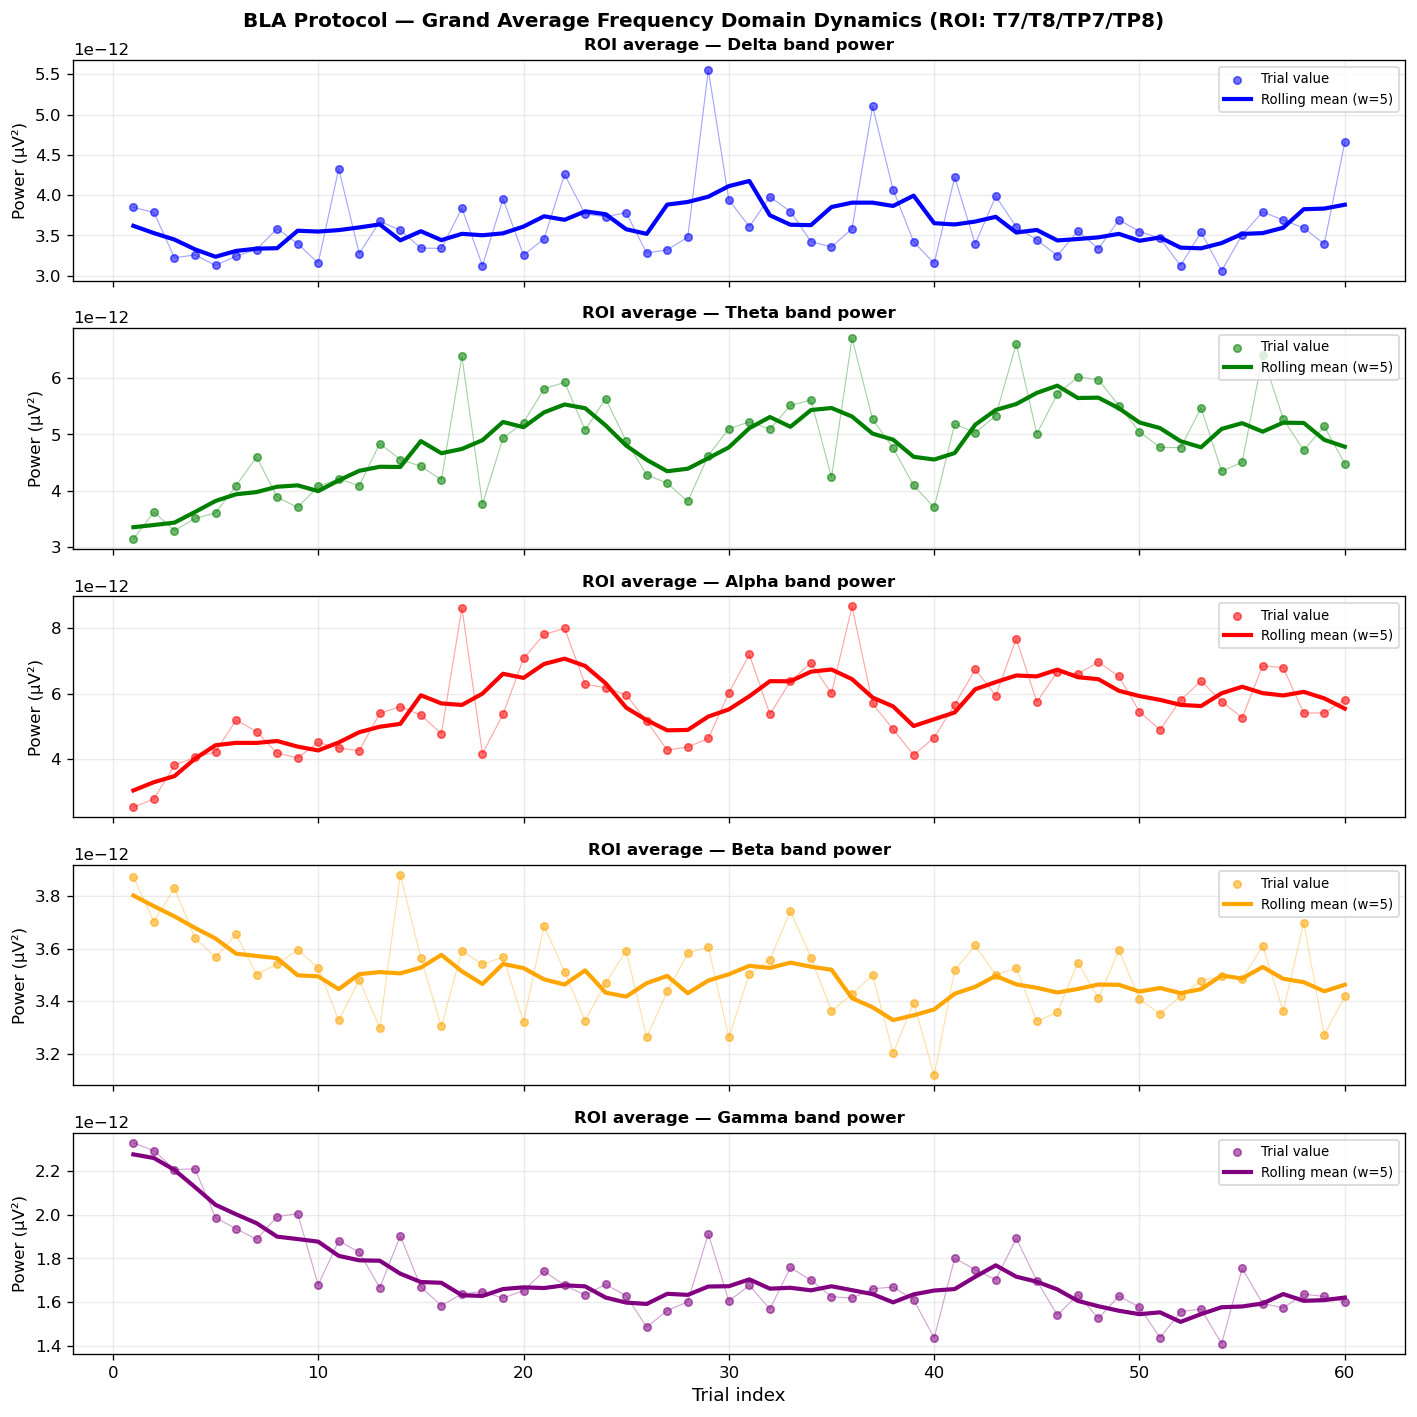

Figure saved: frequency_dynamics_BLA_grand_average.png
Analysis completed for subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Note: Grand average across all available BLA subject data files analyzed.


In [23]:
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# build grand-average power table across subjects
grand_power = {}
for band in bands:
    band_trials = []
    for subject_id in SUBJECTS:
        power_pivot = all_power_pivots[subject_id]
        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        grand_power[band] = pd.concat(band_trials, axis=1).mean(axis=1)

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]
    if band in grand_power:
        values = grand_power[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        s = pd.Series(values)
        rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.5, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

    ax.set_ylabel('Power (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(f'BLA Protocol — Grand Average Frequency Domain Dynamics (ROI: T7/T8/TP7/TP8)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: frequency_dynamics_BLA_grand_average.png")

print(f"Analysis completed for subjects: {SUBJECTS}")
print("Note: Grand average across all available BLA subject data files analyzed.")

Processed successfully in both: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


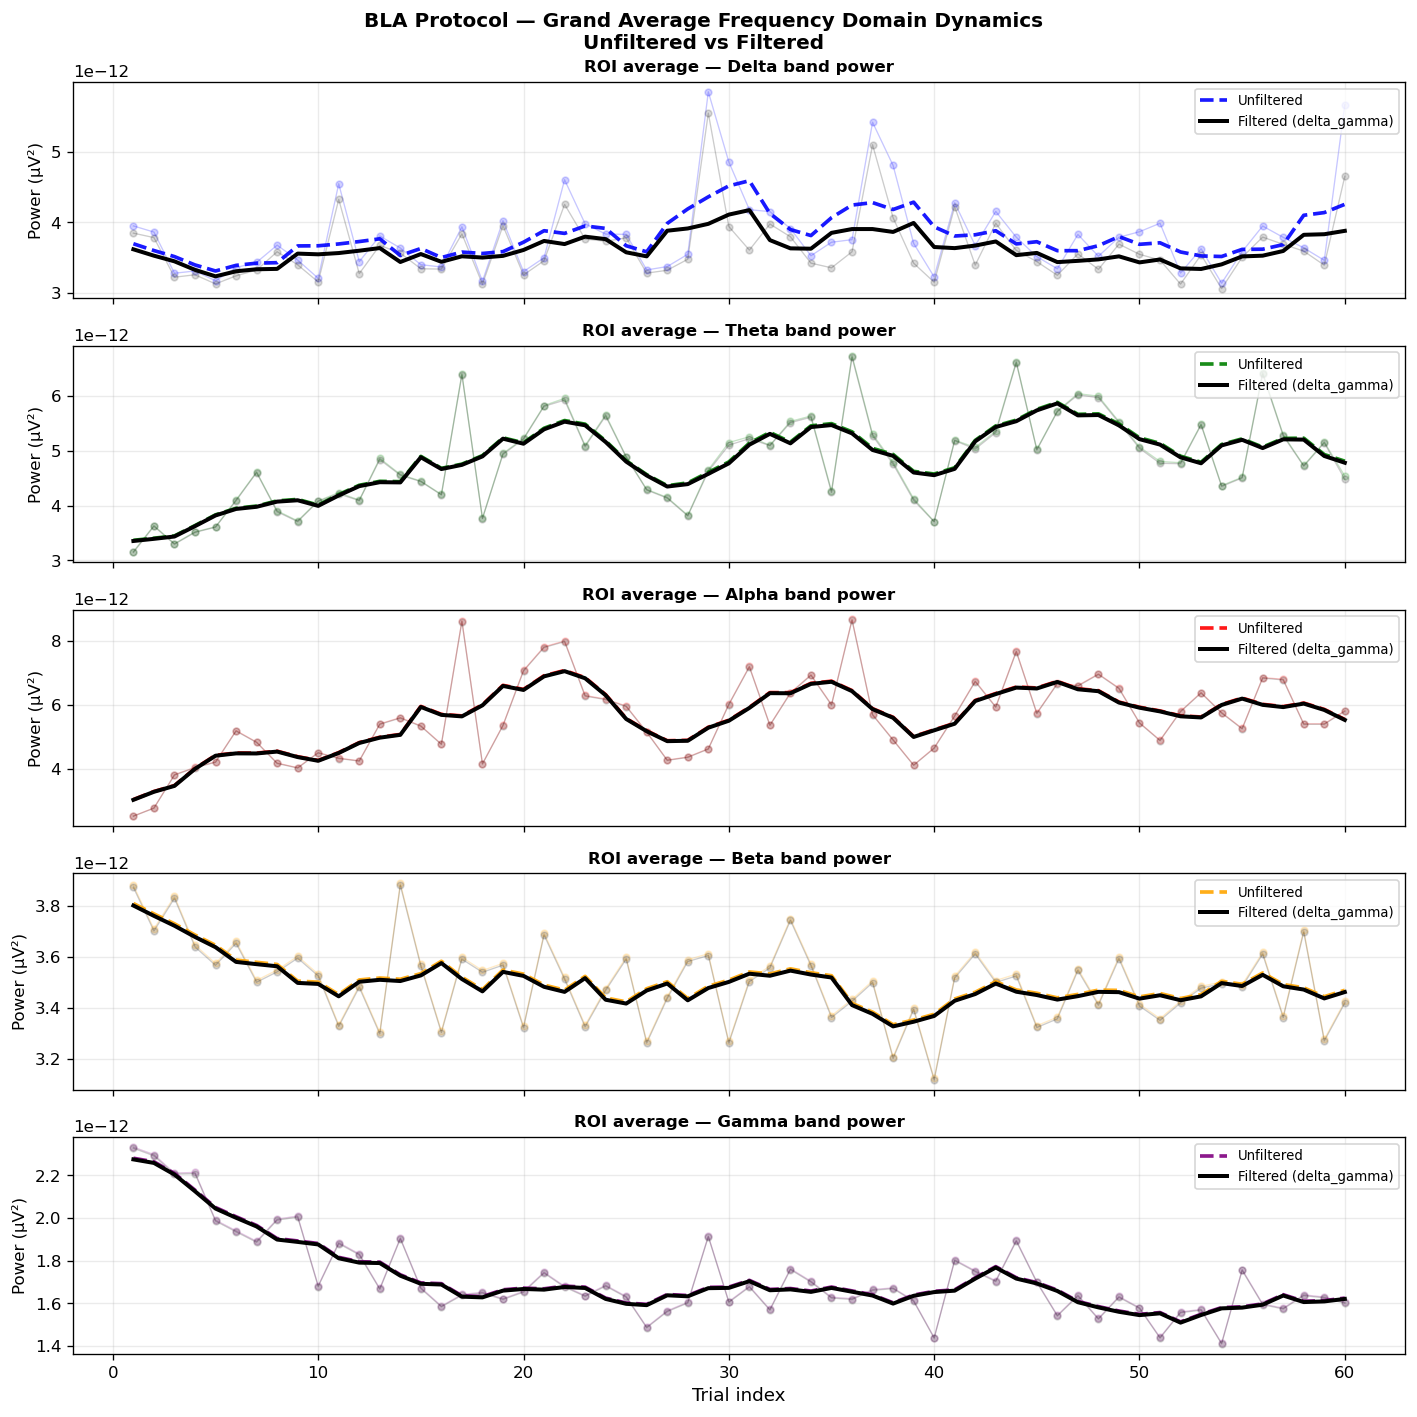


Figure saved: frequency_dynamics_BLA_filtered_vs_unfiltered.png


In [25]:
import warnings
import contextlib
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# GOAL:
# Compare grand-average band power across trials for:
#   1) unfiltered EEG data
#   2) filtered EEG data
# and plot both on the same figure.
# ------------------------------------------------------------

# Frequency bands that will appear as separate subplots
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# Color used for each band
colors = {
    'delta': 'blue',
    'theta': 'green',
    'alpha': 'red',
    'beta': 'orange',
    'gamma': 'purple'
}

# This is the filter applied BEFORE power is computed
# "delta_gamma" in utils corresponds to (0.5, 45) Hz
FILTER_BAND = "delta_gamma"

# ------------------------------------------------------------
# Dictionaries to store power results for each subject
# ------------------------------------------------------------

# Unfiltered results:
#   key   = subject ID
#   value = trial-by-band table of average power
all_power_pivots_unfiltered = {}

# Filtered results:
#   key   = subject ID
#   value = trial-by-band table of average power
all_power_pivots_filtered = {}

# Keep track of which subjects were successfully processed
processed_unfiltered = []
processed_filtered = []

# Keep track of any subjects that fail
failed_unfiltered = []
failed_filtered = []

# ------------------------------------------------------------
# STEP 1: For each subject, compute power twice:
#   A) once using unfiltered data
#   B) once using filtered data
# ------------------------------------------------------------

for subject_id in SUBJECTS:

    # ---------------------------
    # A) UNFILTERED DATA
    # ---------------------------
    try:
        # Suppress warning spam from MNE / utils
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load EEG data normally (no bandpass filter applied here)
                epochs_unf = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS
                )

        # Compute frequency-band power from the unfiltered epochs
        power_df_unf, _ = compute_frequency_power(epochs_unf, fmin=0.5, fmax=45)

        # Rearrange the table so:
        #   rows    = trial number
        #   columns = frequency band
        #   values  = average power across ROI channels
        power_pivot_unf = power_df_unf.groupby(['trial', 'band'])['power'].mean().unstack()

        # Save this subject's unfiltered result
        all_power_pivots_unfiltered[subject_id] = power_pivot_unf
        processed_unfiltered.append(subject_id)

    except Exception as e:
        failed_unfiltered.append((subject_id, str(e)))

    # ---------------------------
    # B) FILTERED DATA
    # ---------------------------
    try:
        # Again suppress warning spam
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load EEG data, but this time apply the filter first
                # so ALL later calculations use the filtered signal
                epochs_filt = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band=FILTER_BAND
                )

        # Compute frequency-band power from the filtered epochs
        power_df_filt, _ = compute_frequency_power(epochs_filt, fmin=0.5, fmax=45)

        # Rearrange into trial x band table
        power_pivot_filt = power_df_filt.groupby(['trial', 'band'])['power'].mean().unstack()

        # Save this subject's filtered result
        all_power_pivots_filtered[subject_id] = power_pivot_filt
        processed_filtered.append(subject_id)

    except Exception as e:
        failed_filtered.append((subject_id, str(e)))

# ------------------------------------------------------------
# STEP 2: Only compare subjects that worked in BOTH cases
# ------------------------------------------------------------

common_subjects = sorted(set(processed_unfiltered) & set(processed_filtered))

print("Processed successfully in both:", common_subjects)

if failed_unfiltered:
    print("\nUnfiltered failed:")
    for subject_id, err in failed_unfiltered:
        print(f"Subject {subject_id}: {err}")

if failed_filtered:
    print("\nFiltered failed:")
    for subject_id, err in failed_filtered:
        print(f"Subject {subject_id}: {err}")

# ------------------------------------------------------------
# STEP 3: Build grand-average trial curves across subjects
# ------------------------------------------------------------
# For each band:
#   - collect that band's trial-by-trial power from every subject
#   - average across subjects at each trial index
# ------------------------------------------------------------

grand_power_unfiltered = {}
grand_power_filtered = {}

for band in bands:
    band_trials_unf = []
    band_trials_filt = []

    for subject_id in common_subjects:
        pivot_unf = all_power_pivots_unfiltered[subject_id]
        pivot_filt = all_power_pivots_filtered[subject_id]

        # If this band exists for the subject, add it to the list
        if band in pivot_unf.columns:
            band_trials_unf.append(pivot_unf[band].reset_index(drop=True))

        if band in pivot_filt.columns:
            band_trials_filt.append(pivot_filt[band].reset_index(drop=True))

    # Combine all subjects side-by-side, then average across columns
    # so we get one grand-average curve for this band
    if band_trials_unf:
        grand_power_unfiltered[band] = pd.concat(band_trials_unf, axis=1).mean(axis=1)

    if band_trials_filt:
        grand_power_filtered[band] = pd.concat(band_trials_filt, axis=1).mean(axis=1)

# ------------------------------------------------------------
# STEP 4: Plot unfiltered and filtered curves together
# ------------------------------------------------------------

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]
    color = colors[band]

    # ---------------------------
    # Plot UNFILTERED results
    # ---------------------------
    if band in grand_power_unfiltered:
        values_unf = grand_power_unfiltered[band].values
        trial_idx_unf = np.arange(1, len(values_unf) + 1)

        # Raw trial points
        ax.scatter(
            trial_idx_unf, values_unf,
            color=color, s=16, alpha=0.18, zorder=1
        )

        # Thin line connecting raw trial values
        ax.plot(
            trial_idx_unf, values_unf,
            color=color, linewidth=0.8, alpha=0.22, zorder=1
        )

        # Smoothed rolling mean to make the trend easier to see
        rolling_unf = pd.Series(values_unf).rolling(
            window=ROLLING_WINDOW, center=True, min_periods=1
        ).mean()

        ax.plot(
            trial_idx_unf, rolling_unf,
            color=color, linewidth=2.2, alpha=0.9, linestyle='--',
            zorder=3, label='Unfiltered'
        )

    # ---------------------------
    # Plot FILTERED results
    # ---------------------------
    if band in grand_power_filtered:
        values_filt = grand_power_filtered[band].values
        trial_idx_filt = np.arange(1, len(values_filt) + 1)

        # Raw trial points
        ax.scatter(
            trial_idx_filt, values_filt,
            color='black', s=16, alpha=0.15, zorder=2
        )

        # Thin line connecting raw trial values
        ax.plot(
            trial_idx_filt, values_filt,
            color='black', linewidth=0.8, alpha=0.20, zorder=2
        )

        # Smoothed rolling mean for filtered data
        rolling_filt = pd.Series(values_filt).rolling(
            window=ROLLING_WINDOW, center=True, min_periods=1
        ).mean()

        ax.plot(
            trial_idx_filt, rolling_filt,
            color='black', linewidth=2.4, zorder=4, label=f'Filtered ({FILTER_BAND})'
        )

    # Labels and formatting for each subplot
    ax.set_ylabel('Power (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

# Shared x-axis label and overall figure title
axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    'BLA Protocol — Grand Average Frequency Domain Dynamics\nUnfiltered vs Filtered',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_filtered_vs_unfiltered.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nFigure saved: frequency_dynamics_BLA_filtered_vs_unfiltered.png")